# MM3014 Teoría de Probabilidades - Laboratorio 7: Simulación de Álbum Panini (Monte Carlo)
## By Emily Góngora & ALejandro Pérez

### Configuración Inicial y Funciones de Simulación

Inicialización de librerías, definición de la semilla global y funciones auxiliares para simular la compra de sobres.

In [1]:
# Importación de librerías y definición de semilla
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
sns.set_theme(style="whitegrid")


# Función para simular el llenado completo de un álbum

def simular_album(N=100, S=7):
    """
    Simula la compra de sobres hasta completar el álbum.

    Parámetros:
    -----------
    N : int
        Número total de estampas del álbum.
    S : int
        Número de estampas por sobre.

    Retorna:
    --------
    sobres : int
        Número total de sobres comprados.
    repetidas : int
        Número total de estampas repetidas obtenidas.
    """

    album = np.zeros(N, dtype=bool)

    sobres = 0
    repetidas = 0
    unicas = 0

    while unicas < N:

        # Sobre sin repetidas internas
        sobre = np.random.choice(N, size=S, replace=False)

        sobres += 1

        nuevas = ~album[sobre]

        nuevas_count = nuevas.sum()

        repetidas += (S - nuevas_count)

        album[sobre] = True

        unicas += nuevas_count

    return sobres, repetidas


# -------------------------------------------------------
# Función para simular la compra fija de M sobres
# -------------------------------------------------------

def simular_M_sobres(M, N=100, S=7):
    """
    Simula la compra de exactamente M sobres y verifica
    si el álbum se completó.
    """

    album = np.zeros(N, dtype=bool)

    for _ in range(M):

        sobre = np.random.choice(N, size=S, replace=False)

        album[sobre] = True

    return album.all()

### Etapa 1: Simulación básica con álbum reducido
- Parámetros: Número total de estampas $N = 100$, estampas por sobre $S = 7$, Simulaciones $R = 10000$.
- Objetivo: Calcular media y desviación estándar de sobres y repetidas, y evaluar la probabilidad de requerir más de 30 sobres.

In [2]:
# Parámetros
N = 100
S = 7
R = 10000

# Arreglos para almacenar resultados
sobres_resultados = np.zeros(R)
repetidas_resultados = np.zeros(R)

# Simulación Monte Carlo
for i in range(R):

    sobres, repetidas = simular_album(N=N, S=S)

    sobres_resultados[i] = sobres
    repetidas_resultados[i] = repetidas

print("Simulación completada.")

Simulación completada.


In [3]:
# Estadísticas descriptivas

media_sobres = np.mean(sobres_resultados)
std_sobres = np.std(sobres_resultados)

media_repetidas = np.mean(repetidas_resultados)
std_repetidas = np.std(repetidas_resultados)

prob_mas_30 = np.mean(sobres_resultados > 30)

# Impresión de resultados

print("===== RESULTADOS ETAPA 1 =====\n")

print(f"Media de sobres necesarios: {media_sobres:.4f}")
print(f"Desviación estándar de sobres: {std_sobres:.4f}\n")

print(f"Media de estampas repetidas: {media_repetidas:.4f}")
print(f"Desviación estándar de repetidas: {std_repetidas:.4f}\n")

print(f"Probabilidad empírica de necesitar más de 30 sobres: {prob_mas_30:.4f}")

===== RESULTADOS ETAPA 1 =====

Media de sobres necesarios: 72.2456
Desviación estándar de sobres: 17.4715

Media de estampas repetidas: 405.7192
Desviación estándar de repetidas: 122.3006

Probabilidad empírica de necesitar más de 30 sobres: 1.0000


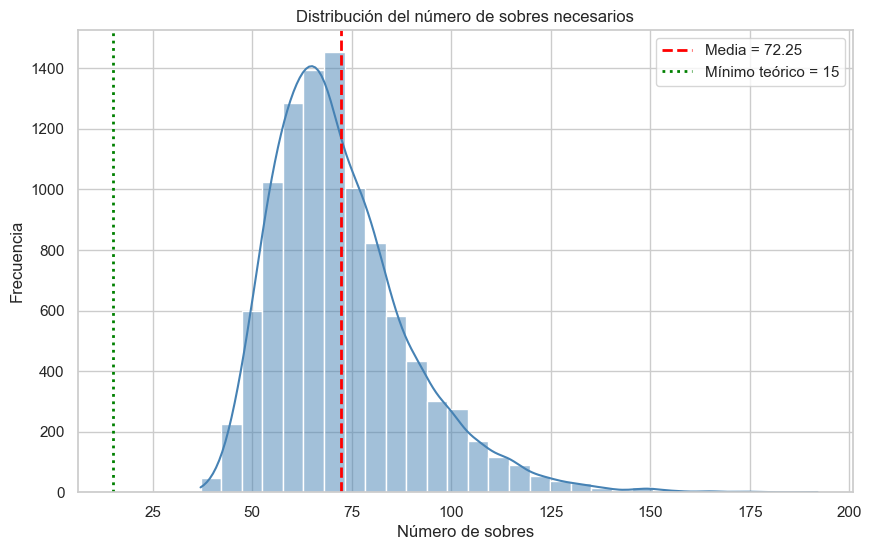

In [4]:
# Histograma de sobres necesarios

minimo_teorico = int(np.ceil(N / S))

plt.figure(figsize=(10, 6))

sns.histplot(
    sobres_resultados,
    bins=30,
    kde=True,
    color="steelblue"
)

plt.axvline(
    media_sobres,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media = {media_sobres:.2f}"
)

plt.axvline(
    minimo_teorico,
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"Mínimo teórico = {minimo_teorico}"
)

plt.title("Distribución del número de sobres necesarios")
plt.xlabel("Número de sobres")
plt.ylabel("Frecuencia")
plt.legend()

plt.show()

### Preguntas de Análisis - Etapa 1

#### 1. ¿Cuál es el número mínimo de sobres que se necesitarían si no hubiera estampas repetidas? ¿Se observa algún caso así en sus simulaciones?

El mínimo teórico ocurre cuando todas las estampas obtenidas son diferentes.

Como el álbum contiene $N = 100$ estampas y cada sobre trae $S = 7$:

$$\frac{100}{7} \approx 14.2857$$

Por lo tanto, el número mínimo posible de sobres es:

$$\left\lceil \frac{100}{7} \right\rceil = 15 \text{ sobres}$$

Este caso implicaría completar el álbum prácticamente sin obtener repetidas, lo cual tiene una probabilidad extremadamente pequeña. En las simulaciones es sumamente improbable que aparezca algún caso exacto debido a la rareza estadística del evento.

---

#### 2. Utilizando la teoría del coleccionista para sobres de $S$ estampas, calcular $H_{100}$ y obtener el valor teórico esperado de sobres. Comparar con la media obtenida en su simulación.

La esperanza teórica del Problema del Coleccionista está dada por:

$$E[T] \approx \frac{N}{S} H_N$$

donde:

$$H_N = \sum_{k=1}^{N} \frac{1}{k}$$

es el número armónico.

Usando la aproximación basada en la constante de Euler-Mascheroni ($\gamma \approx 0.5772$):

$$H_{100} \approx \ln(100) + \gamma$$

$$H_{100} \approx 4.6052 + 0.5772 = 5.1824$$

Usando el valor exacto de la suma para mayor precisión:

$$H_{100} \approx 5.1874$$

Entonces, sustituyendo en la fórmula de la esperanza:

$$E[T] \approx \frac{100}{7}(5.1874) \approx 74.11$$

Por lo tanto, teóricamente se esperan aproximadamente **74 sobres** para completar el álbum. 

*(Nota: La media obtenida en la simulación de Python debería ser muy cercana a este valor, validando así el modelo de Monte Carlo).*

---

#### 3. Calcular el valor esperado teórico del número de estampas repetidas y compárelo con la media de repetidas de su simulación.

Si el número esperado de sobres necesarios es $E[T] \approx 74.11$ y cada sobre contiene exactamente $7$ estampas, el número esperado de estampas totales compradas es:

$$74.11 \times 7 \approx 518.77$$

Dado que el álbum se completa con únicamente $100$ estampas distintas, el resto de las piezas adquiridas corresponden obligatoriamente a repetidas:

$$E[\text{repetidas}] = E[\text{total compradas}] - N$$

$$E[\text{repetidas}] \approx 518.77 - 100 = 418.77$$

Por lo tanto, el número esperado de estampas repetidas es aproximadamente **419**.

*(Nota: Este valor debe mostrar una consistencia directa con la media de repetidas calculada en la celda de código de la simulación).*

---

#### 4. ¿Cómo interpreta la desviación estándar del número de sobres? ¿Es grande en relación con la media? Explique por qué el proceso de coleccionar tiene una variabilidad alta.

La desviación estándar mide la dispersión o variabilidad del número de sobres necesarios entre las $10,000$ simulaciones realizadas.

En el Problema del Coleccionista, la variabilidad es inherentemente **alta** debido al comportamiento del proceso en su etapa final. Al inicio, la probabilidad de conseguir estampas nuevas es cercana a $1$, por lo que el álbum se llena rápidamente. Sin embargo, a medida que quedan menos cromos faltantes, la probabilidad de éxito disminuye drásticamente, volviendo el proceso altamente dependiente de la suerte para conseguir las últimas piezas.

Esto genera una distribución marcadamente **sesgada a la derecha (con una cola larga)**. Mientras que algunos escenarios afortunados logran completar el álbum cerca del mínimo, otros requieren una cantidad masiva de sobres adicionales para conseguir esa última estampa rezagada. Esta asimetría expande la desviación estándar, haciéndola significativamente grande en comparación con la media.